## END-TO-END EDA  ##

# STUDENT PERFORMANCE DATA #

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/students-performance-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\rabieelkharoua\students-performance-dataset\versions\2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")
# Load the dataset
df = pd.read_csv("C:\\Users\\USER\\Desktop\\B\\Student_performance_data _.csv")
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0


In [ ]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [ ]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

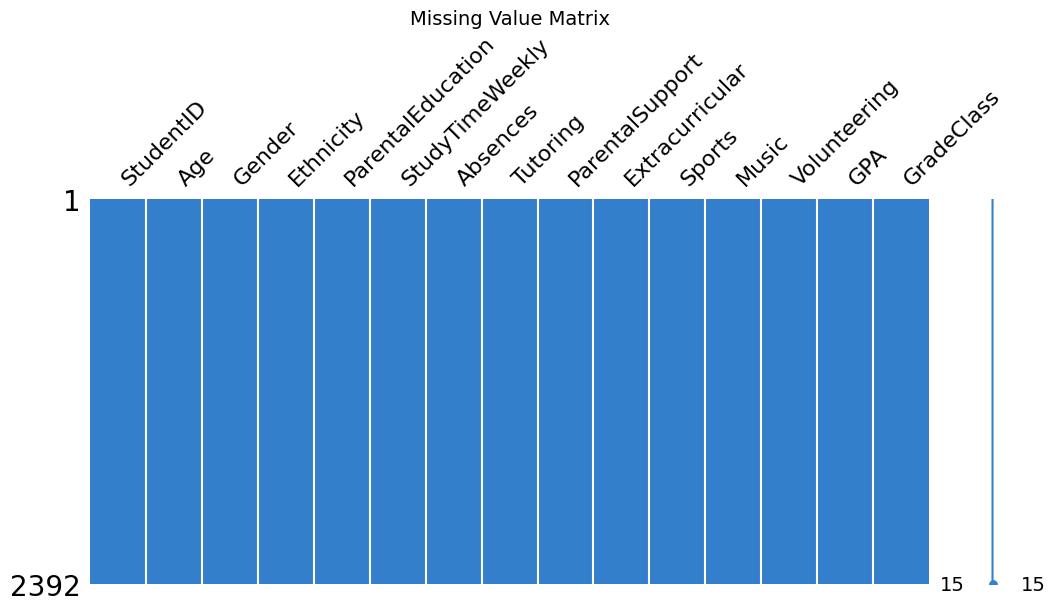

In [ ]:
# Missing value matrix visualisation
import missingno as msno
msno.matrix(df, figsize=(12, 5), color=(0.2, 0.5, 0.8))
plt.title("Missing Value Matrix", fontsize=14)
plt.show()

The missing value matrix indicates that the dataset contains no missing values across all features. Each variable is fully populated, and there is no evidence of incomplete observations. Therefore, no missing data preprocessing is required

In [ ]:
df.describe(include='all')

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [ ]:
# Check for duplicates
print(" DUPLICATE ROWS:", df.duplicated().sum())

# Check for StudentID uniqueness
print(" Unique StudentIDs:", df['StudentID'].nunique(), "out of", len(df))

 DUPLICATE ROWS: 0
 Unique StudentIDs: 2392 out of 2392


In [ ]:
#DATA CLEANING
#Drop StudentID (identifier, not a feature)
df.drop(columns=['StudentID'], inplace=True)
print("Dropped 'StudentID'")

#Define the proper semantic types
categorical_cols = ['Gender', 'Ethnicity', 'ParentalEducation',
                    'Tutoring', 'ParentalSupport',
                    'Extracurricular', 'Sports', 'Music', 'Volunteering']

continuous_cols  = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']
target_col       = 'GradeClass'

#Cast categoricals to 'category' dtype
for col in categorical_cols:
    df[col] = df[col].astype('category')

#GradeClass is ordinal — cast to int then category
df[target_col] = df[target_col].astype(int).astype('category')

print("\nData types after casting:")
print(df.dtypes)

Dropped 'StudentID'

Data types after casting:
Age                     int64
Gender               category
Ethnicity            category
ParentalEducation    category
StudyTimeWeekly       float64
Absences                int64
Tutoring             category
ParentalSupport      category
Extracurricular      category
Sports               category
Music                category
Volunteering         category
GPA                   float64
GradeClass           category
dtype: object


Columns were grouped into categorical,continuous, and target lists
to make downstream operations explicit and organised.

All categorical features were cast to category dtype to reduce memory
usage and improve performance during grouping and visualisation.

The target variable GradeClass was first cast to int (to remove any floating-
point residuals) and then to category, ensuring it is treated as a discrete
class label rather than a continuous numeric value throughout the analysis.

In [ ]:
#Decode encoded labels for readability (keep original, add decoded versions)
df['Gender_label']           = df['Gender'].map({0: 'Male', 1: 'Female'})
df['Ethnicity_label']        = df['Ethnicity'].map({0: 'Caucasian', 1: 'African American',
                                                    2: 'Asian', 3: 'Other'})
df['ParentalEducation_label']= df['ParentalEducation'].map({0: 'None', 1: 'High School',
                                                            2: 'Some College',
                                                            3: "Bachelor's", 4: 'Higher'})
df['ParentalSupport_label']  = df['ParentalSupport'].map({0: 'None', 1: 'Low',
                                                          2: 'Moderate', 3: 'High', 4: 'Very High'})
df['GradeClass_label']       = df['GradeClass'].map({0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'})

print(" Decoded label columns added")
df.head()

 Decoded label columns added


,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,Gender_label,Ethnicity_label,ParentalEducation_label,ParentalSupport_label,GradeClass_label
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2,Female,Caucasian,Some College,Moderate,C
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1,Male,Caucasian,High School,Low,B
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4,Male,Asian,Bachelor's,Moderate,F
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3,Female,Caucasian,Bachelor's,High,D
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4,Female,Caucasian,Some College,High,F


Several columns in the dataset use integer codes to represent categorical values.
To improve readability during exploratory analysis and visualisation, human-readable
label columns were created alongside the originals using .map() method.

Decoded label columns were added for Gender, Ethnicity, ParentalEducation,
ParentalSupport, and GradeClass mapping each numeric code to its real-world
meaning (e.g., GradeClass: 0 → A, 1 → B, 2 → C, 3 → D, 4 → F).

The original numeric columns were preserved to ensure compatibility with
machine learning pipelines, while the label columns are used exclusively
for plots and summary tables.

In [ ]:
#Outlier detection using IQR on continuous columns
print("OUTLIER REPORT (IQR method):\n")
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col:20s} → lower: {lower:.2f}, upper: {upper:.2f}, outliers: {n_out}")

OUTLIER REPORT (IQR method):

  Age                  → lower: 12.00, upper: 20.00, outliers: 0
  StudyTimeWeekly      → lower: -9.00, upper: 28.46, outliers: 0
  Absences             → lower: -15.50, upper: 44.50, outliers: 0
  GPA                  → lower: -1.00, upper: 4.79, outliers: 0


The IQR analysis revealed **no outliers** in any of the four continuous
features. All values fall within the calculated lower and upper fences,
indicating the dataset is clean with no extreme values requiring treatment.

As a result, winsorization or any outlier removal step was **not applied**,
preserving the full integrity of the data for modelling.

## UNIVARAITE ANALYSIS

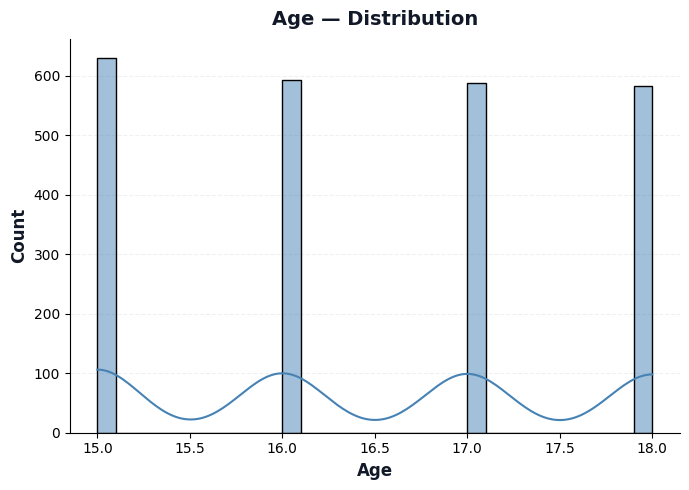

In [ ]:
fig, axes = plt.subplots(figsize=(7, 5))

sns.histplot(df['Age'], kde=True, ax=axes, color='steelblue', bins=30)
axes.set_title('Age — Distribution', fontsize=14, fontweight='bold', color='#111827', pad=10)
axes.set_xlabel('Age', fontsize=12, fontweight='bold', color='#111827')
axes.set_ylabel('Count', fontsize=12, fontweight='bold', color='#111827')
axes.tick_params(axis='both', labelsize=10)
axes.yaxis.grid(True, linestyle='--', alpha=0.6, color='#E5E7EB')
axes.set_axisbelow(True)
axes.set_facecolor('white')
sns.despine(ax=axes)

plt.tight_layout()
plt.show()

### Age
The distribution of `Age` is distinctly **discrete**, with values appearing only
at 15, 16, 17, and 18  no fractional ages exist in the dataset. Each age group
holds a roughly equal count of around 580–640 students, indicating a
**well-balanced, uniform spread** across year groups. The KDE curve dips between
age points because there are no in-between values, reflecting the integer nature
of the variable rather than any real gap in the data.

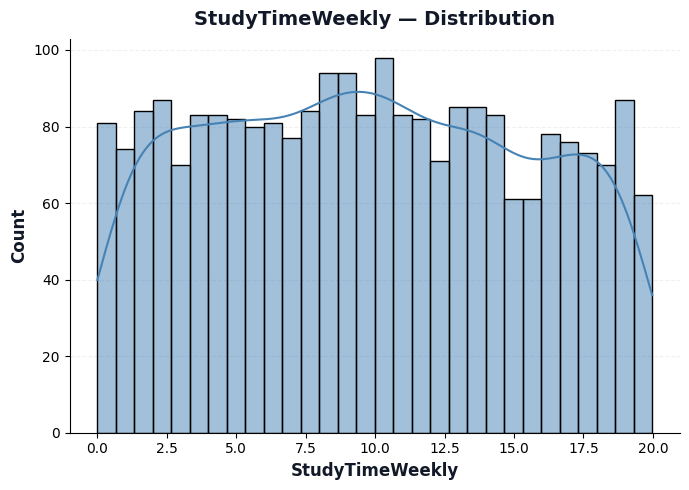

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(df['StudyTimeWeekly'], kde=True, ax=ax, color='steelblue', bins=30)
ax.set_title('StudyTimeWeekly — Distribution', fontsize=14, fontweight='bold', color='#111827', pad=10)
ax.set_xlabel('StudyTimeWeekly', fontsize=12, fontweight='bold', color='#111827')
ax.set_ylabel('Count', fontsize=12, fontweight='bold', color='#111827')
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#E5E7EB')
ax.set_axisbelow(True)
ax.set_facecolor('white')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### StudyTimeWeekly
`StudyTimeWeekly` follows a **broadly uniform distribution** ranging from 0 to
20 hours per week, with a slight peak between 7.5 and 10 hours. No single study
habit dominates  students are relatively evenly spread across the full range.
The gentle KDE curve confirms there is no strong central tendency, suggesting
study habits vary widely across the student population.


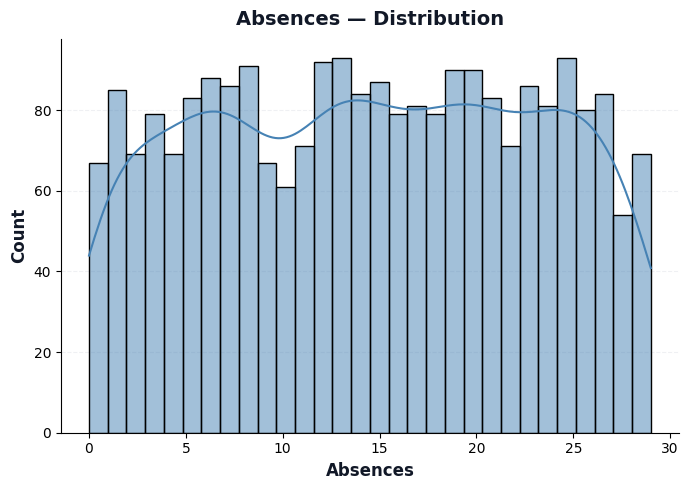

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(df['Absences'], kde=True, ax=ax, color='steelblue', bins=30)
ax.set_title('Absences — Distribution', fontsize=14, fontweight='bold', color='#111827', pad=10)
ax.set_xlabel('Absences', fontsize=12, fontweight='bold', color='#111827')
ax.set_ylabel('Count', fontsize=12, fontweight='bold', color='#111827')
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#E5E7EB')
ax.set_axisbelow(True)
ax.set_facecolor('white')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Absences
`Absences` displays a **near-uniform distribution** from 0 to approximately 28
days, with counts consistently hovering between 65 and 90 across most bins.
The KDE curve shows a mild bell shape peaking around 10–15 absences, with a
gradual tail-off beyond 25. This indicates most students have moderate absences,
with fewer students at the extreme low or high ends.

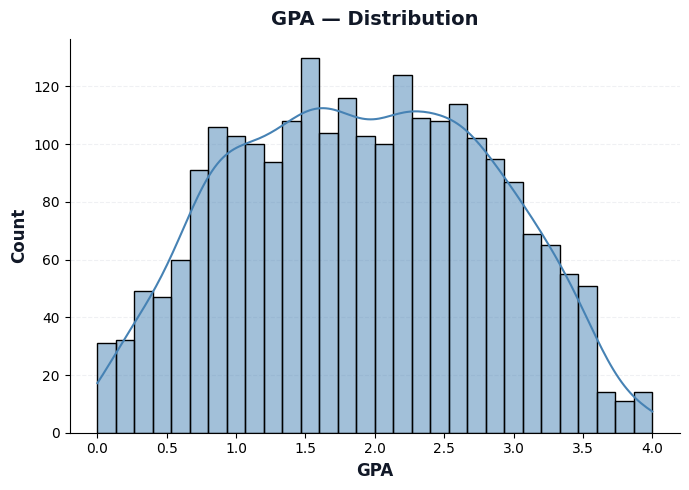

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(df['GPA'], kde=True, ax=ax, color='steelblue', bins=30)
ax.set_title('GPA — Distribution', fontsize=14, fontweight='bold', color='#111827', pad=10)
ax.set_xlabel('GPA', fontsize=12, fontweight='bold', color='#111827')
ax.set_ylabel('Count', fontsize=12, fontweight='bold', color='#111827')
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#E5E7EB')
ax.set_axisbelow(True)
ax.set_facecolor('white')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### GPA
`GPA` shows a **right-skewed distribution**, peaking around 1.5–2.0 and
gradually tapering toward 4.0. The bulk of students fall between GPA 1.0 and
3.0, with relatively few achieving above 3.5. The KDE curve confirms the
asymmetry most students cluster in the low-to-mid GPA range, with high
achievers forming a long but thin upper tail.

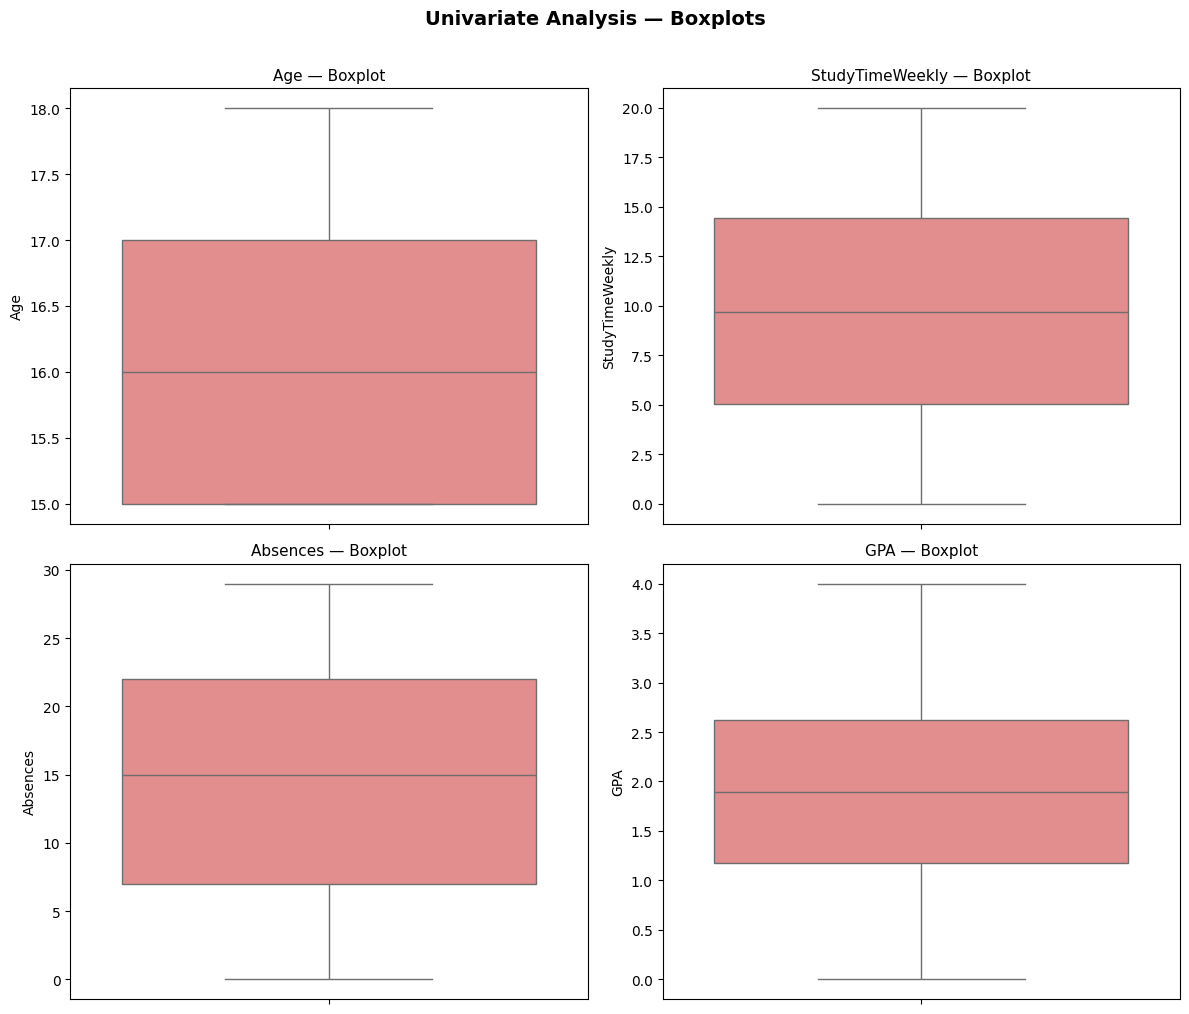

In [ ]:
# UNIVARIATE — Continuous Variables (Boxplots)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col} — Boxplot', fontsize=11)

plt.suptitle("Univariate Analysis — Boxplots", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Age
The boxplot confirms `Age` spans from **15 to 18**, with a median at **16**.
The box is fairly symmetric, with Q1 at 15 and Q3 at 17, giving an IQR of 2 years.
No outliers are present. This reinforces that the dataset represents a typical
high school cohort with an even spread across four year groups.

### StudyTimeWeekly
The median study time sits at approximately **9–10 hours per week**, with the
middle 50% of students studying between roughly **5 and 14 hours**. The whiskers
extend fully from 0 to 20 hours, indicating the full possible range is utilised
with no outliers. The box is slightly asymmetric, with a longer lower half,
suggesting a mild left skew some students study very little, pulling the
lower whisker further down.

### Absences
`Absences` has a median of approximately **15 days**, with the IQR spanning
from around **8 to 22 days**. Whiskers reach from 0 to just under 30, covering
the full range without any flagged outliers. The box is fairly symmetric,
confirming the uniform distribution seen in the histogram. The wide IQR
highlights that absence behaviour varies considerably across students.

### GPA
The median GPA is approximately **1.9**, with Q1 around 1.3 and Q3 around 2.6,
giving an IQR of roughly 1.3 points. The upper whisker extends to 4.0 while the
lower whisker reaches near 0, with no outliers flagged. The longer upper whisker
compared to the lower half confirms the **right skew** observed in the histogram
while most students sit in the lower-to-mid GPA range, a smaller group achieves
significantly higher grades.

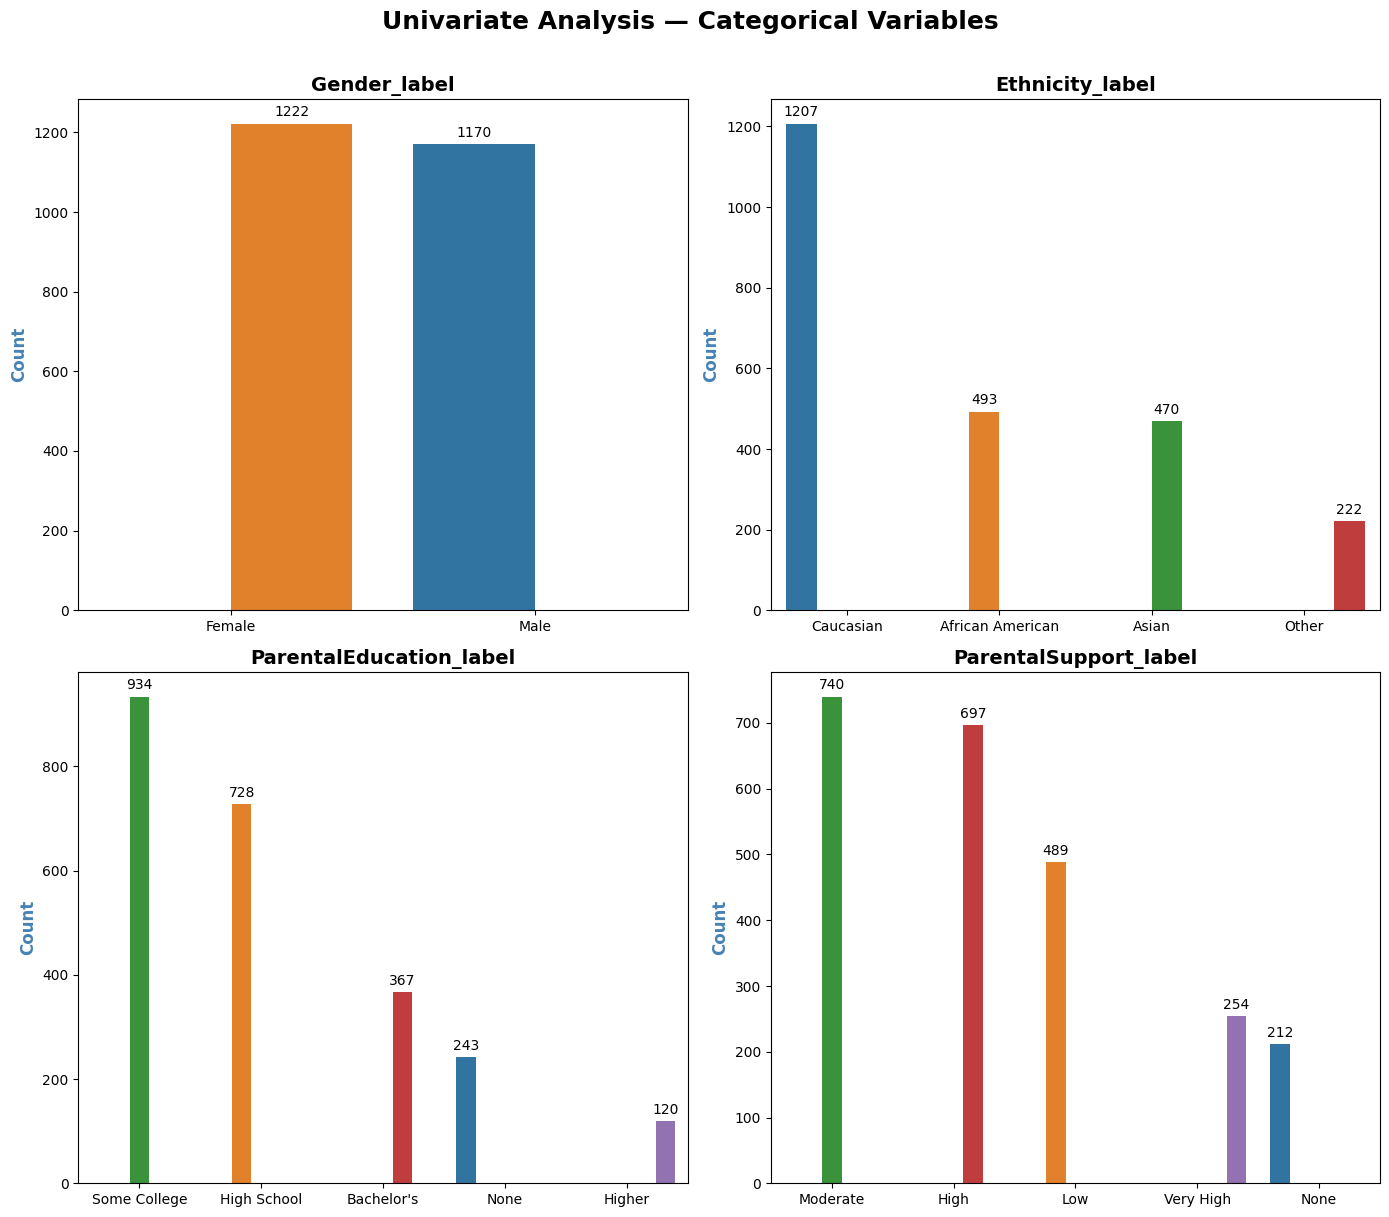

In [ ]:

# UNIVARIATE — Categorical Variables


cat_plot_cols_1 = ['Gender_label', 'Ethnicity_label', 
                   'ParentalEducation_label', 'ParentalSupport_label']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols_1):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i],
                hue=counts.index, palette='tab10',        # ← hue added here
                order=counts.index, legend=False)
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=12, fontweight='bold', color='steelblue')
    for bar in axes[i].patches:
        height = bar.get_height()
        axes[i].annotate(f'{int(height)}', 
                         xy=(bar.get_x() + bar.get_width() / 2, height), 
                         xytext=(0, 3), textcoords='offset points', 
                         ha='center', va='bottom', fontsize=10)
       
plt.suptitle("Univariate Analysis — Categorical Variables ", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

this plots is actually showing counts per each categorical columns. looking into the first plot, we will see that female gender is more than the male gender.
looking into the ethnicity label too, the plot shows total number of student from each ethnic background.

## BIVARIATE ANALYSIS

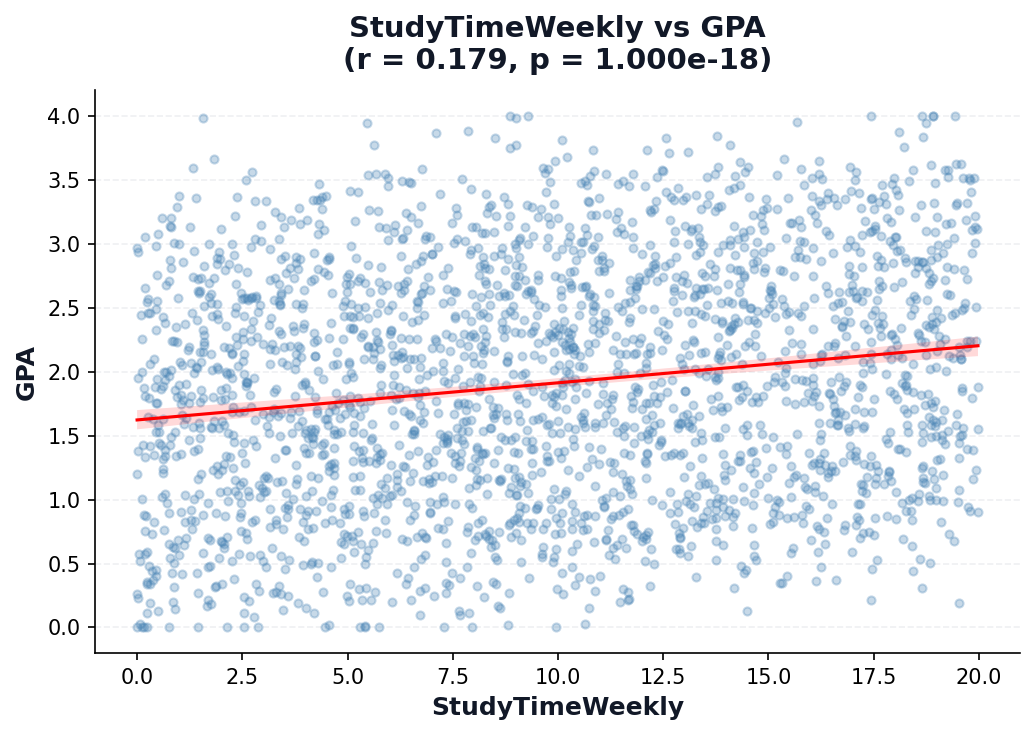

In [ ]:
from scipy import stats

ffig, ax = plt.subplots(figsize=(7, 5), dpi=150)

median_study = df['StudyTimeWeekly'].median()
for group, color, label in [
    (df['StudyTimeWeekly'] <= median_study, '#e74c3c', 'Low Study Time'),
    (df['StudyTimeWeekly']  > median_study, '#2ecc71', 'High Study Time')
]:
    ax.scatter(df.loc[group, 'StudyTimeWeekly'], df.loc[group, 'GPA'],
               color=color, label=label, alpha=0.4, s=18,
               edgecolors='white', linewidths=0.3, zorder=3)

sns.regplot(data=df, x='StudyTimeWeekly', y='GPA', ax=ax,
            scatter=False,
            line_kws={'color': 'red', 'linewidth': 1.5}, zorder=4)

r, p = stats.pearsonr(df['StudyTimeWeekly'], df['GPA'])
ax.set_title(f'StudyTimeWeekly vs GPA\n(r = {r:.3f}, p = {p:.3e})',
             fontsize=14, fontweight='bold', color='#111827', pad=10)
ax.set_xlabel('StudyTimeWeekly', fontsize=12, fontweight='bold', color='#111827')
ax.set_ylabel('GPA',             fontsize=12, fontweight='bold', color='#111827')
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#E5E7EB')
ax.set_axisbelow(True)
ax.set_facecolor('white')
ax.legend(title='Study Time', fontsize=9, framealpha=0.9, edgecolor='#D1D5DB')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

This is a regression plot showing the relationship between two variables (GPA VS STW) the red line is the regression line that shows the general direction and strength of the relationship between the variables.


r stands for **correlation coefficient** while p stands for **probability value**,
StudyTimeWeekly shows a weak but statistically significant positive relationship
with GPA (r = 0.179, p < 0.001). While students who study more tend to achieve
slightly higher GPAs on average, the wide scatter indicates that study time alone
explains very little of the variation in GPA. Other factors likely play a stronger
role in determining student academic performance. 

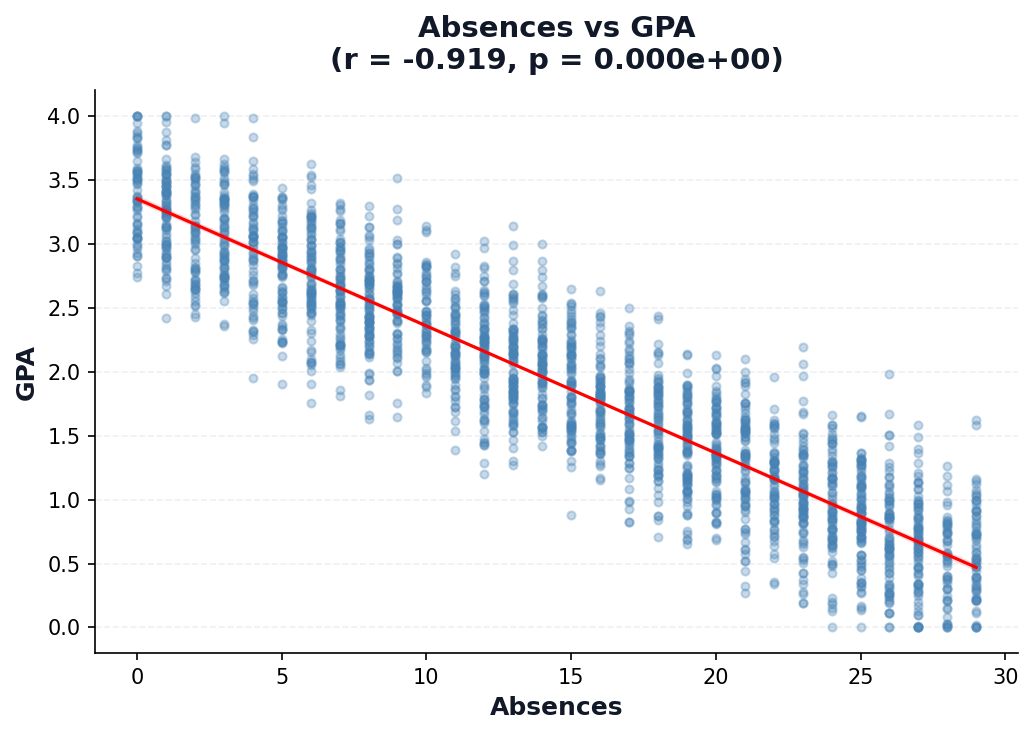

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

sns.regplot(data=df, x='Absences', y='GPA', ax=ax,
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 1.5})

r, p = stats.pearsonr(df['Absences'], df['GPA'])
ax.set_title(f'Absences vs GPA\n(r = {r:.3f}, p = {p:.3e})',
             fontsize=14, fontweight='bold', color='#111827', pad=10)
ax.set_xlabel('Absences', fontsize=12, fontweight='bold', color='#111827')
ax.set_ylabel('GPA', fontsize=12, fontweight='bold', color='#111827')
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#E5E7EB')
ax.set_axisbelow(True)
ax.set_facecolor('white')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Absences is by far the strongest predictor of GPA in this dataset, showing a
near perfect negative correlation (r = -0.919, p < 0.001). Students with more
absences consistently achieve significantly lower GPAs, with GPA dropping
sharply across the full absence range. This variable will almost certainly
be the most influential feature in any predictive model built on this dataset.

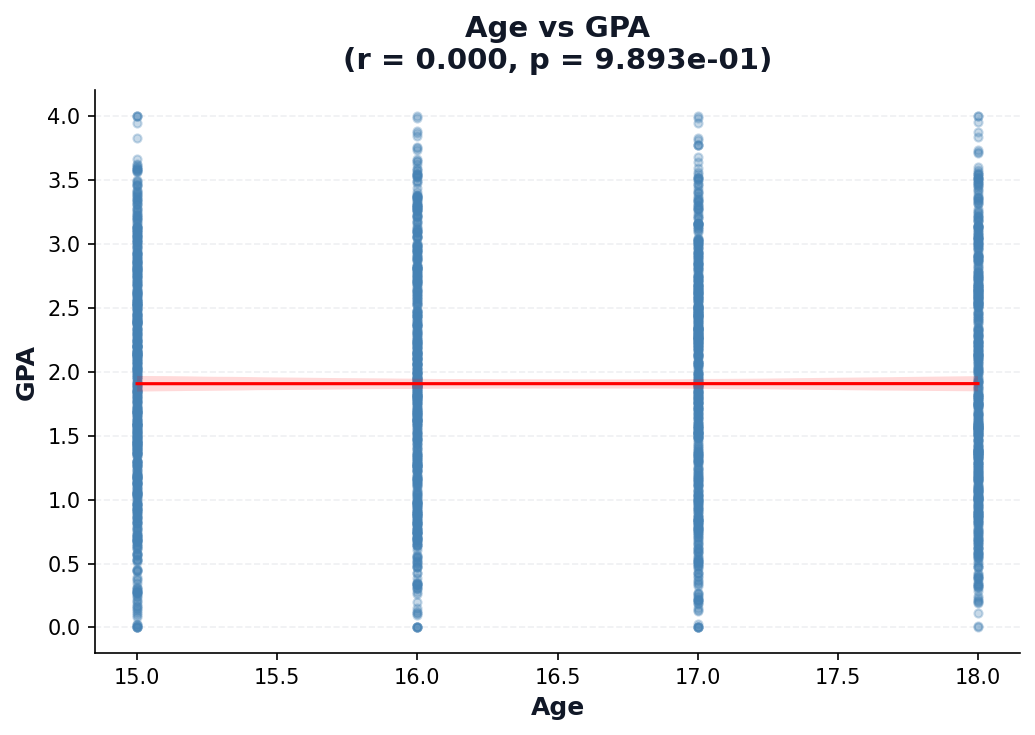

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

sns.regplot(data=df, x='Age', y='GPA', ax=ax,
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 1.5})

r, p = stats.pearsonr(df['Age'], df['GPA'])
ax.set_title(f'Age vs GPA\n(r = {r:.3f}, p = {p:.3e})',
             fontsize=14, fontweight='bold', color='#111827', pad=10)
ax.set_xlabel('Age', fontsize=12, fontweight='bold', color='#111827')
ax.set_ylabel('GPA', fontsize=12, fontweight='bold', color='#111827')
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#E5E7EB')
ax.set_axisbelow(True)
ax.set_facecolor('white')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Age shows absolutely no correlation with GPA (r = 0.000, p = 0.989),
meaning a student's age provides zero predictive value for academic
performance. The four discrete age groups 15, 16, 17, and 18, all
produce an identical GPA spread from 0.0 to 4.0 with the same average

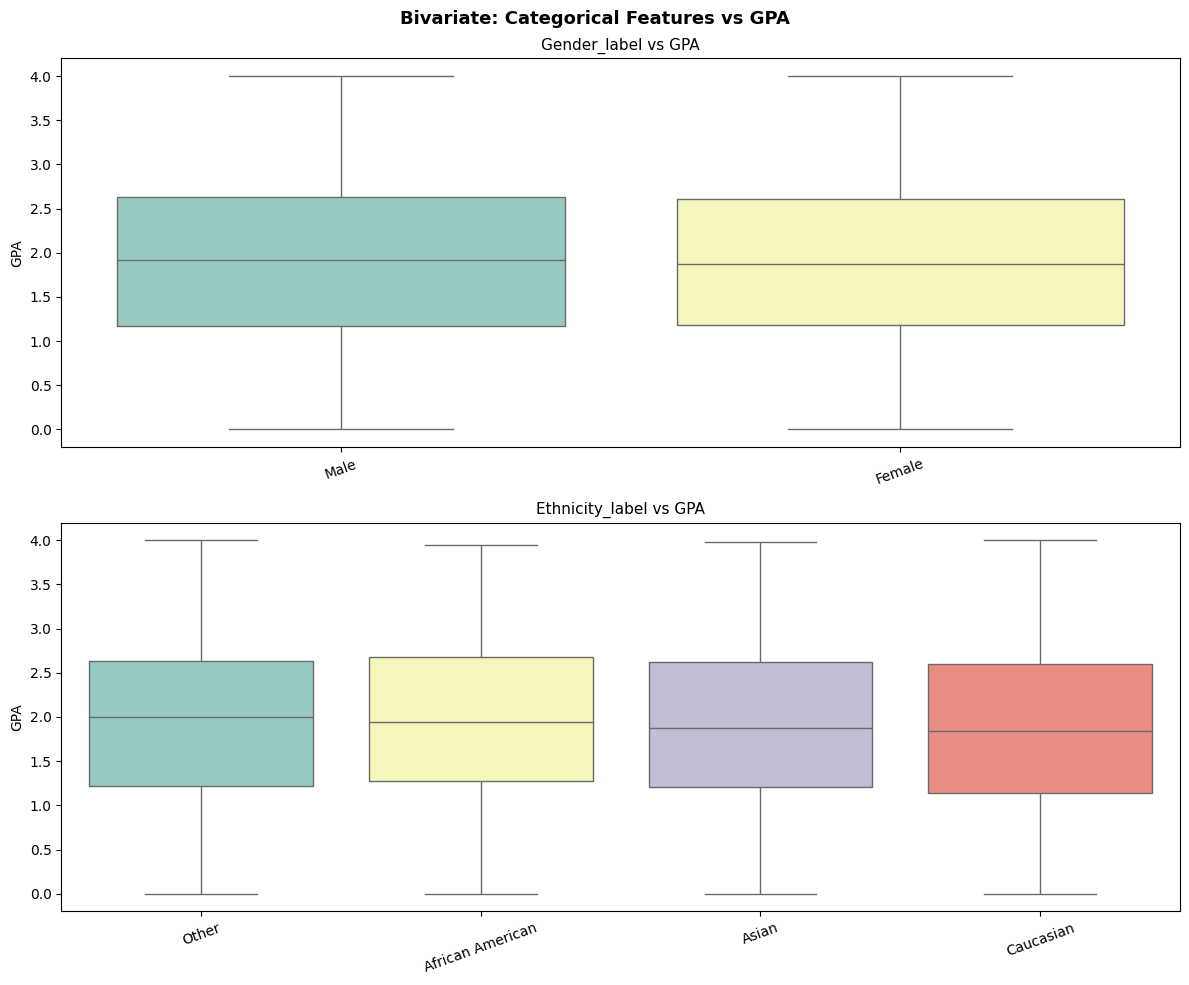

In [ ]:
# BIVARIATE — Categorical vs GPA (boxplots)

cat_bivar = ['Gender_label', 'Ethnicity_label']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cat_bivar):
    order = df.groupby(col)['GPA'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='GPA', ax=axes[i],
                order=order, palette='Set3')
    axes[i].set_title(f'{col} vs GPA', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle("Bivariate: Categorical Features vs GPA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Neither Gender nor Ethnicity shows any huge difference in GPA
distribution across their respective groups. All medians sit tightly
around 1.85–2.00, with near identical spreads and ranges. This suggests
that both variables carry very little predictive signal for GPA and may
contribute minimal value during feature selection for modelling.

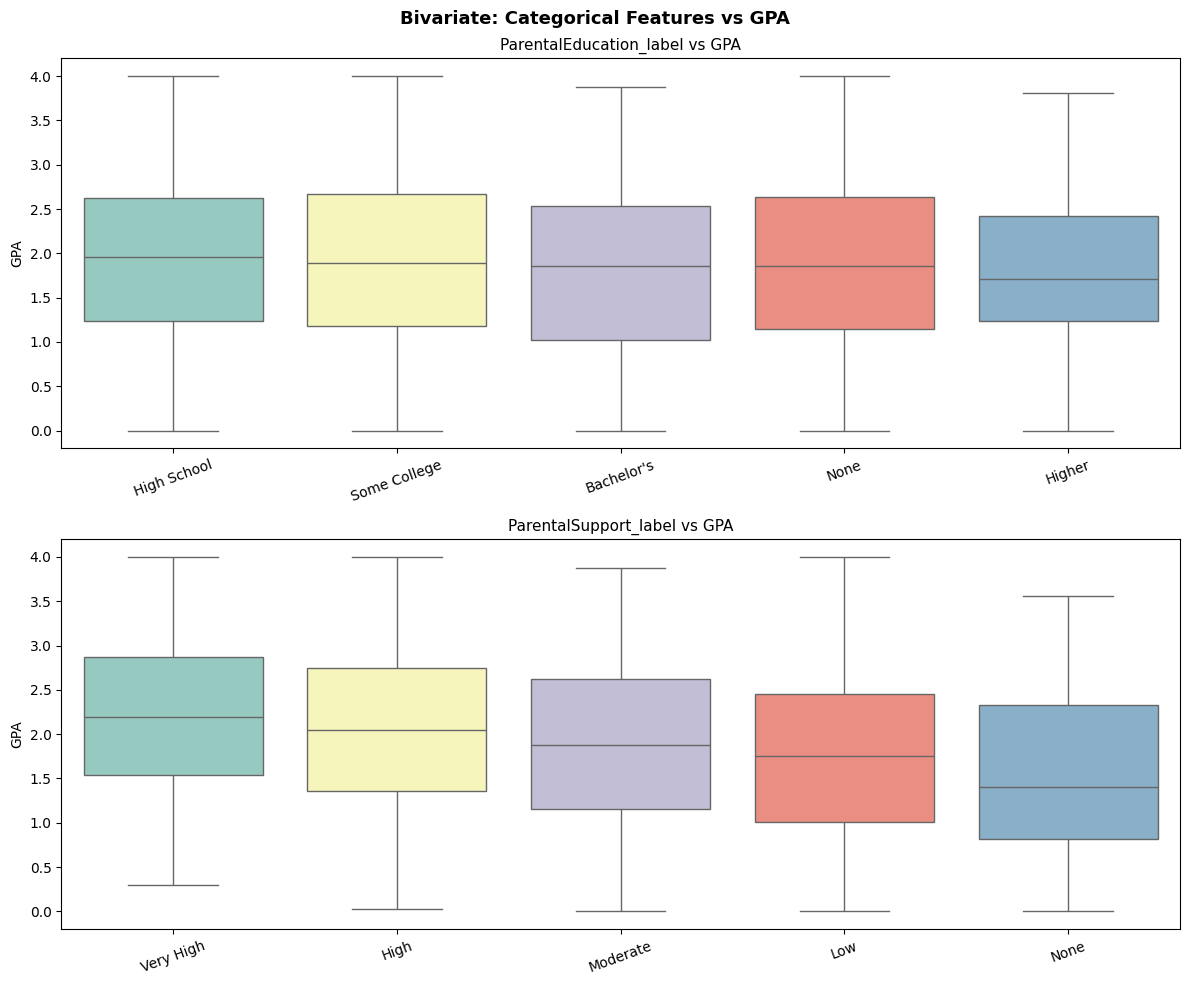

In [ ]:
# BIVARIATE — Categorical vs GPA (boxplots)
cat_bivar = ['ParentalEducation_label', 'ParentalSupport_label']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cat_bivar):
    order = df.groupby(col)['GPA'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='GPA', ax=axes[i],
                order=order, palette='Set3')
    axes[i].set_title(f'{col} vs GPA', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle("Bivariate: Categorical Features vs GPA", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Parental Support, reveals a clear positive pattern, students with
higher levels of parental support consistently achieve higher GPAs, with
median GPA dropping steadily from 2.20 (Very High support) down to 1.50
(No support). This makes Parental Support a potentially useful feature
for modelling, unlike Parental Education.

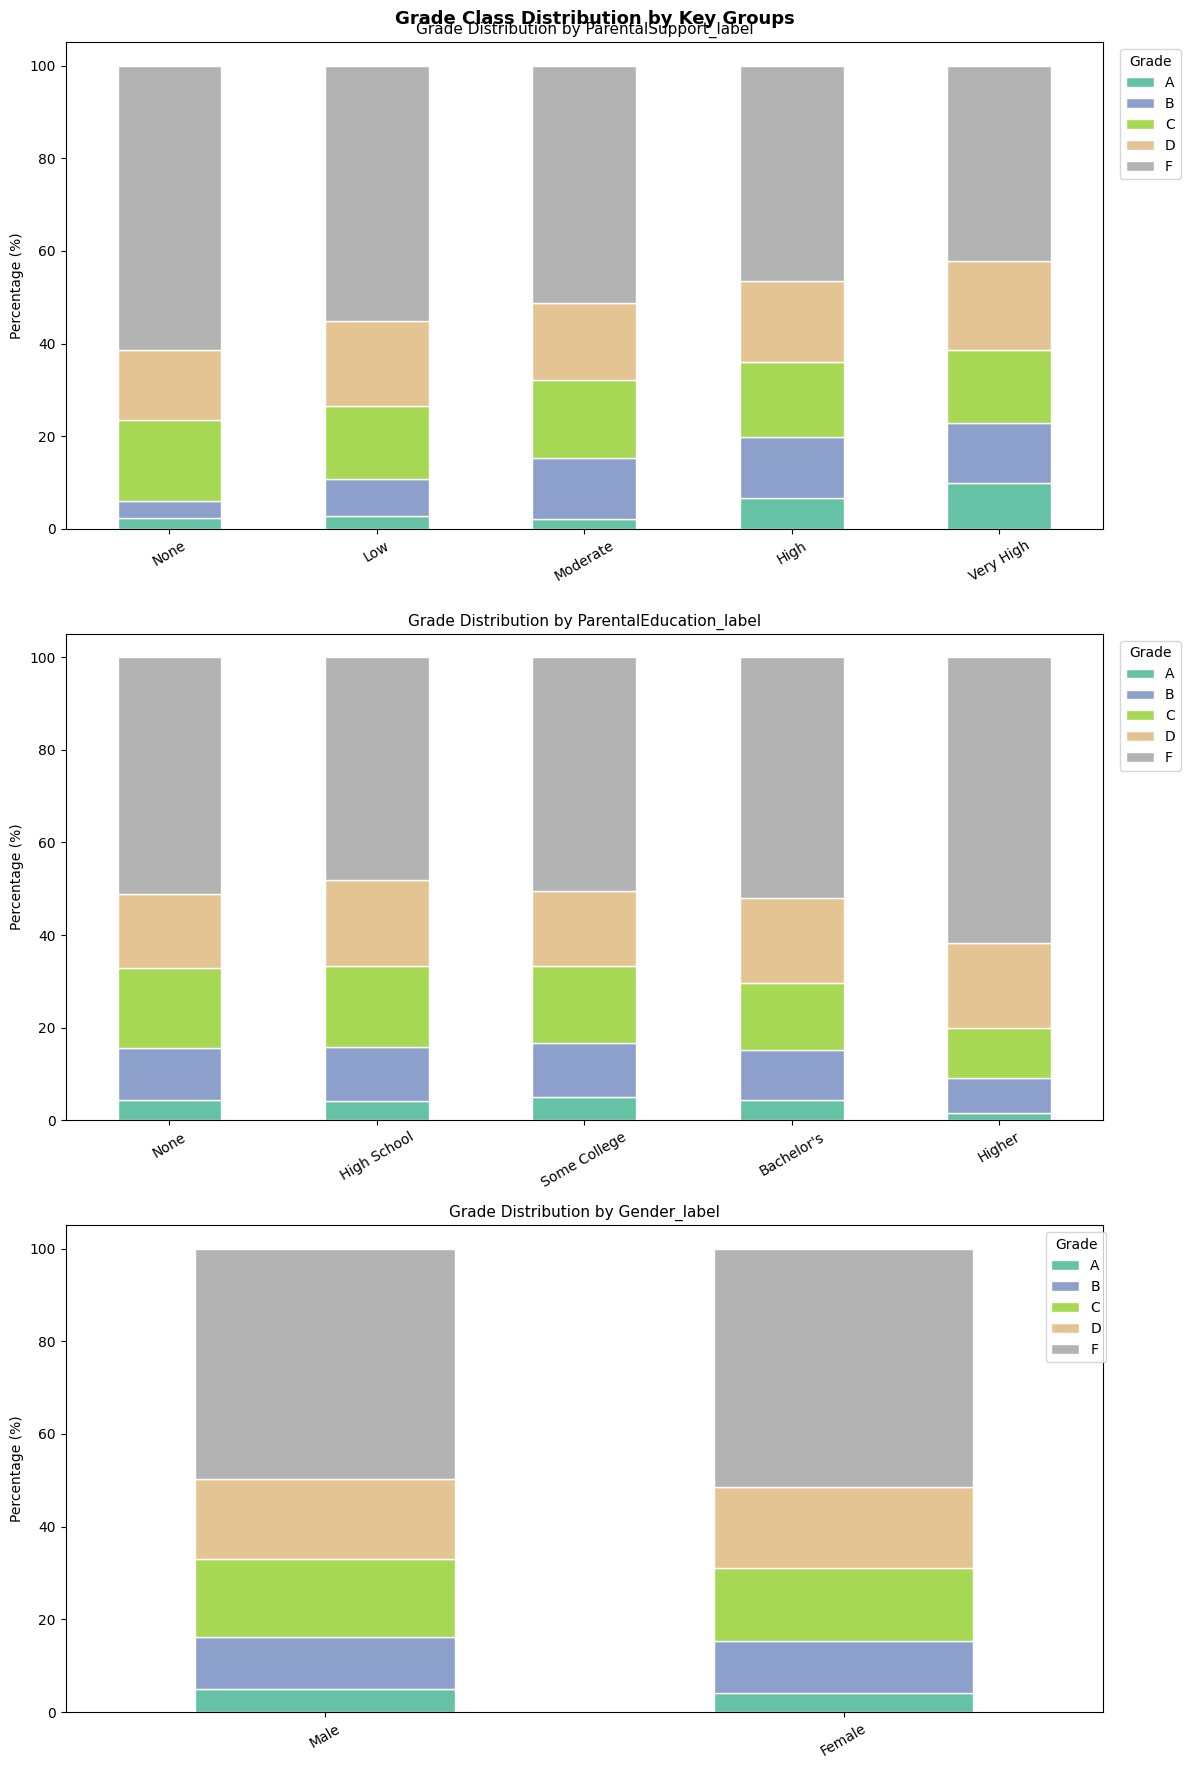

In [ ]:

# BIVARIATE — GradeClass distribution across key groups
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for ax, col in zip(axes, ['ParentalSupport_label', 'ParentalEducation_label', 'Gender_label']):
    ct = pd.crosstab(df[col], df['GradeClass_label'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'Grade Distribution by {col}', fontsize=11)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Grade', bbox_to_anchor=(1.01, 1))

plt.suptitle("Grade Class Distribution by Key Groups", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Across all three categorical breakdowns, Parental Support stands out as
the only variable showing a meaningful and consistent relationship with
grade class distribution. As support increases, F grade proportions
decrease and higher grade proportions grow steadily.

Parental Education and Gender both show flat, undifferentiated grade
distributions across all their categories, confirming they carry little
to no predictive value for GradeClass.

## MULTIVARIATE ANALYSIS

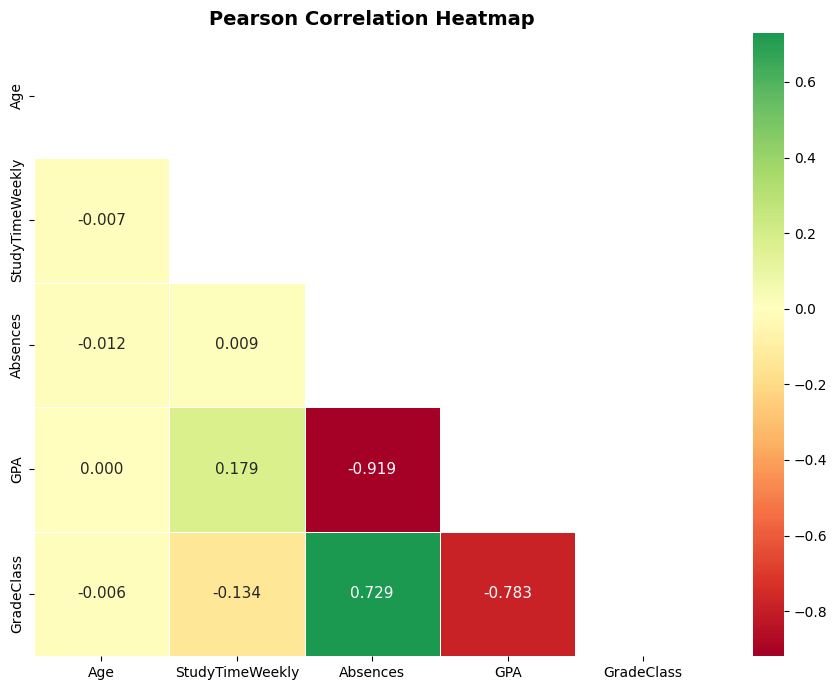

In [ ]:
# CORRELATION HEATMAP

# Encode for correlation (use numeric form only)
df_numeric = df[continuous_cols + ['GradeClass']].copy()
df_numeric['GradeClass'] = df_numeric['GradeClass'].astype(int)

corr_matrix = df_numeric.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 11}, ax=ax)
ax.set_title("Pearson Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The Pearson Correlation Heatmap confirms that Absences is the most critical
feature in the dataset, with near perfect negative correlation with GPA
(-0.919) and strong positive correlation with GradeClass (0.729). Age shows
zero correlation with every other variable and should be considered for
removal during feature selection. StudyTimeWeekly has a weak but present
signal, while GPA and GradeClass are strongly linked as expected given
that GradeClass is derived directly from GPA values.

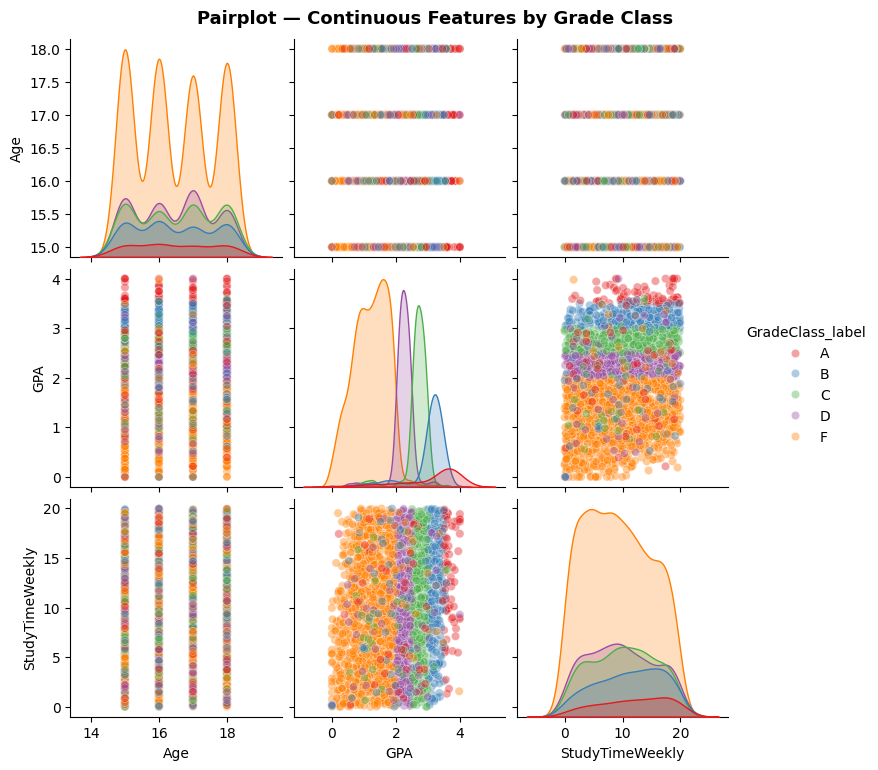

In [ ]:
# PAIRPLOT

pair_df = df[['Age', 'GPA', 'StudyTimeWeekly', 'GradeClass_label']].copy()
g = sns.pairplot(pair_df, hue='GradeClass_label',
                 palette='Set1', plot_kws={'alpha': 0.4}, diag_kind='kde')
g.fig.suptitle("Pairplot — Continuous Features by Grade Class", 
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

The pairplot reveals that GPA is the only continuous feature that cleanly
separates the five grade classes, with each grade occupying a distinct GPA
band as shown by the well-separated KDE curves on the diagonal. Age shows
no separation whatsoever across any panel, reinforcing its status as a
non-informative feature. StudyTimeWeekly produces overlapping distributions
across all grade classes, offering only marginal discriminative power.
These findings confirm that Absences and GPA are the strongest signals
in the dataset, while Age should be a strong candidate for removal
during feature selection.

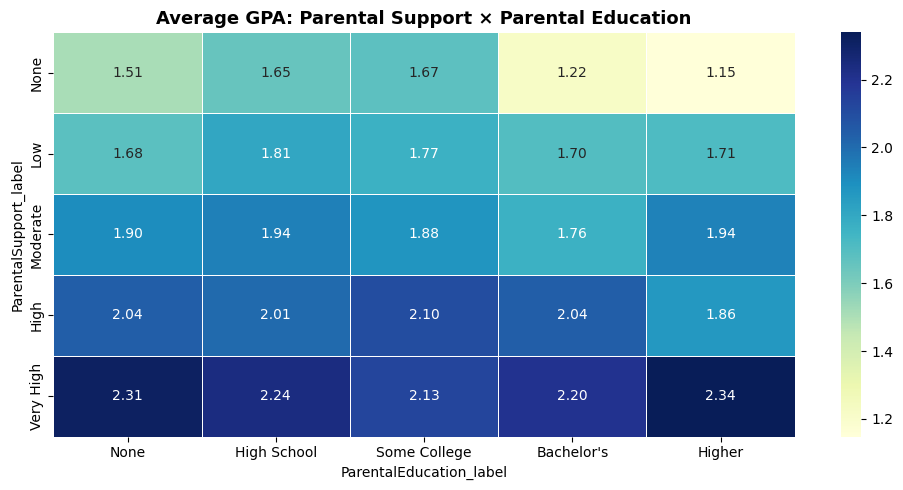

In [ ]:
#AVERAGE GPA HEATMAP — ParentalSupport × ParentalEducation
pivot = df.pivot_table(values='GPA',
                       index='ParentalSupport_label',
                       columns='ParentalEducation_label',
                       aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5, ax=ax)
ax.set_title("Average GPA: Parental Support × Parental Education", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The interaction heatmap confirms that Parental Support is the dominant driver
of GPA across all parental education levels. Average GPA rises consistently
and significantly with each support level, from a low of ~1.2–1.7 at no
support to ~2.1–2.3 at very high support. Parental Education shows no
consistent directional effect, its impact is negligible once support level
is accounted for. A student with highly supportive but less educated parents
consistently outperforms a student with highly educated but unsupportive
parents, making Parental Support the more valuable feature for modelling.

## Preprocessing for ML ##

In [ ]:
# PREPROCESSING FOR MACHINE LEARNING

# Create a clean ML-ready dataframe (drop decoded label columns)
label_cols = [c for c in df.columns if c.endswith('_label')]
df_ml = df.drop(columns=label_cols).copy()

# Re-encode all categoricals to int
for col in df_ml.select_dtypes(['category']).columns:
    df_ml[col] = df_ml[col].astype(int)

print("✅ ML dataframe shape:", df_ml.shape)
print(df_ml.dtypes)

✅ ML dataframe shape: (2392, 14)
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass             int64
dtype: object


In [ ]:
# Define features and target
X = df_ml.drop(columns=['GradeClass'])
y = df_ml['GradeClass']

print("Features:", list(X.columns))
print("Target distribution:\n", y.value_counts().sort_index())

Features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']
Target distribution:
 GradeClass
0     107
1     269
2     391
3     414
4    1211
Name: count, dtype: int64


In [ ]:
# 10c — Feature scaling: StandardScaler on continuous, passthrough on binary
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scale_cols  = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']
binary_cols = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring',
               'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

preprocessor = ColumnTransformer(transformers=[
    ('scaler', StandardScaler(), scale_cols),
    ('passthrough', 'passthrough', binary_cols)
])

X_processed = preprocessor.fit_transform(X)
feature_names = scale_cols + binary_cols
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("Preprocessing complete. Scaled shape:", X_processed_df.shape)
X_processed_df.head(3)

Preprocessing complete. Scaled shape: (2392, 13)


,Age,StudyTimeWeekly,Absences,GPA,Gender,Ethnicity,ParentalEducation,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering
0,0.472919,1.780336,-0.890822,1.118086,1.0,0.0,2.0,1.0,2.0,0.0,0.0,1.0,0.0
1,1.362944,0.997376,-1.717694,1.242374,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.307132,-0.984045,1.353542,-1.960277,0.0,2.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
# Train / Validation / Test Split  (70 / 15 / 15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed_df, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)
# 0.1765 of 85% ≈ 15% of total

print(f" Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"   Proportions: {len(X_train)/len(X):.0%} / {len(X_val)/len(X):.0%} / {len(X_test)/len(X):.0%}")

 Train: 1674 | Val: 359 | Test: 359
   Proportions: 70% / 15% / 15%
